# CNN evaluation — `vivo`

Cross-domain vivo features.

Loads the fixed baseline CNN and evaluates on this dataset's CQT features. Results are written under `./cnn-eval-results/` next to this notebook.

Only the config cell should differ across dataset copies.

## Config

In [1]:
# --- per-dataset config (only this cell should differ across copies) ---
DATASET = "vivo"
FEATURES_NAME = "vivo.npz"
DESCRIPTION = "Cross-domain vivo features"

from pathlib import Path

def find_training_root(start: Path) -> Path:
    """Walk upward until we find the training/ dir that holds features/ and models/."""
    for candidate in [start, *start.parents]:
        if (candidate / "features").is_dir() and (candidate / "models").is_dir():
            return candidate
        nested = candidate / "training"
        if (nested / "features").is_dir() and (nested / "models").is_dir():
            return nested
    raise FileNotFoundError(
        f"Could not locate training root (features/ + models/) from {start}"
    )

# Robust to Jupyter cwd = notebook dir or repo root.
TRAINING_ROOT = find_training_root(Path.cwd().resolve())
FEATURES_PATH = TRAINING_ROOT / "features" / FEATURES_NAME
MODEL_PATH = TRAINING_ROOT / "models" / "model-bn-c64-c128-c256-c256-d256.keras"
# Always write next to this dataset notebook, not depending on cwd.
RESULTS_DIR = TRAINING_ROOT / "notebooks" / DATASET / "cnn-eval-results"

RANDOM_STATE = 42
# Keep small to avoid multi-kernel GPU OOM on laptop GPUs
BATCH_SIZE = 16
TF_CPP_MIN_LOG_LEVEL = "3"

print(f"DATASET     : {DATASET}")
print(f"DESCRIPTION : {DESCRIPTION}")
print(f"FEATURES    : {FEATURES_PATH}")
print(f"MODEL       : {MODEL_PATH}")
print(f"RESULTS_DIR : {RESULTS_DIR}")
assert FEATURES_PATH.is_file(), f"Missing features: {FEATURES_PATH}"
assert MODEL_PATH.is_file(), f"Missing model: {MODEL_PATH}"


DATASET     : vivo
DESCRIPTION : Cross-domain vivo features
FEATURES    : /home/seya/code/chord-detection/training/features/vivo.npz
MODEL       : /home/seya/code/chord-detection/training/models/model-bn-c64-c128-c256-c256-d256.keras
RESULTS_DIR : /home/seya/code/chord-detection/training/notebooks/vivo/cnn-eval-results


## Setup

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = TF_CPP_MIN_LOG_LEVEL
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

import random
import numpy as np
import tensorflow as tf

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as exc:
        print("GPU memory growth already set:", exc)
print("TensorFlow", tf.__version__, "| GPUs:", gpus)


TensorFlow 2.15.0 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Load model & features

In [3]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.preprocessing import LabelEncoder
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

tf.keras.backend.clear_session()
model = tf.keras.models.load_model(MODEL_PATH)
with np.load(FEATURES_PATH, allow_pickle=True) as data:
    features = data["features"]
    labels = np.asarray(data["labels"]).astype(str)
    files = data["files"] if "files" in data.files else None

print("features:", features.shape, features.dtype)
print("labels  :", labels.shape, "n_classes=", len(np.unique(labels)))
if files is not None:
    print("files   :", len(files))
print("model input :", model.input_shape)
print("model output:", model.output_shape)


features: (1440, 216, 188) float32
labels  : (1440,) n_classes= 36
files   : 1440
model input : (None, 216, 188, 1)
model output: (None, 36)


## Evaluate

In [4]:
# Canonical class order from training features when available (stable across evals)
TRAINING_FEATURES = TRAINING_ROOT / "features" / "training.npz"
if TRAINING_FEATURES.is_file():
    with np.load(TRAINING_FEATURES, allow_pickle=True) as train_data:
        class_names = np.sort(np.unique(np.asarray(train_data["labels"]).astype(str)))
else:
    class_names = np.sort(np.unique(labels))

label_encoder = LabelEncoder()
label_encoder.fit(class_names)

unknown = sorted(set(labels) - set(class_names))
if unknown:
    raise ValueError(f"Eval labels not in training class set: {unknown[:10]}")

y_true = label_encoder.transform(labels)
x = features
if x.ndim == 3:
    x = np.expand_dims(x, axis=-1)
x = x.astype(np.float32, copy=False)

proba = model.predict(x, batch_size=BATCH_SIZE, verbose=1)
y_pred = np.argmax(proba, axis=1)

acc = accuracy_score(y_true, y_pred)
precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

summary = pd.DataFrame(
    [
        {
            "dataset": DATASET,
            "description": DESCRIPTION,
            "features_path": str(FEATURES_PATH),
            "model_path": str(MODEL_PATH),
            "num_samples": int(len(labels)),
            "num_classes": int(len(class_names)),
            "accuracy": float(acc),
            "macro_precision": float(precision_m),
            "macro_recall": float(recall_m),
            "macro_f1": float(f1_m),
            "weighted_precision": float(precision_w),
            "weighted_recall": float(recall_w),
            "weighted_f1": float(f1_w),
        }
    ]
)

report_dict = classification_report(
    y_true,
    y_pred,
    labels=np.arange(len(class_names)),
    target_names=list(class_names),
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report_dict).T
cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))

print("=== Summary ===")
display(summary)
print("=== Classification report (head) ===")
display(report_df.head(12))


 1/90 [..............................] - ETA: 37s

 4/90 [>.............................] - ETA: 1s 

 6/90 [=>............................] - ETA: 1s

 8/90 [=>............................] - ETA: 1s

11/90 [==>...........................] - ETA: 1s

...

90/90 [==============================] - 2s 21ms/step


=== Summary ===


,dataset,description,features_path,model_path,num_samples,num_classes,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
0,vivo,Cross-domain vivo features,/home/seya/code/chord-detection/training/featu...,/home/seya/code/chord-detection/training/model...,1440,36,0.945833,0.949536,0.945833,0.937388,0.949536,0.945833,0.937388


=== Classification report (head) ===


,precision,recall,f1-score,support
A#_diminished_4,1.0,1.000,1.000000,40.0
A#_major_4,1.0,1.000,1.000000,40.0
A#_minor_4,1.0,1.000,1.000000,40.0
A_diminished_4,1.0,1.000,1.000000,40.0
A_major_4,1.0,1.000,1.000000,40.0
A_minor_4,1.0,1.000,1.000000,40.0
B_diminished_4,1.0,1.000,1.000000,40.0
B_major_4,1.0,1.000,1.000000,40.0
B_minor_4,1.0,0.975,0.987342,40.0
C#_diminished_4,1.0,1.000,1.000000,40.0


## Save results

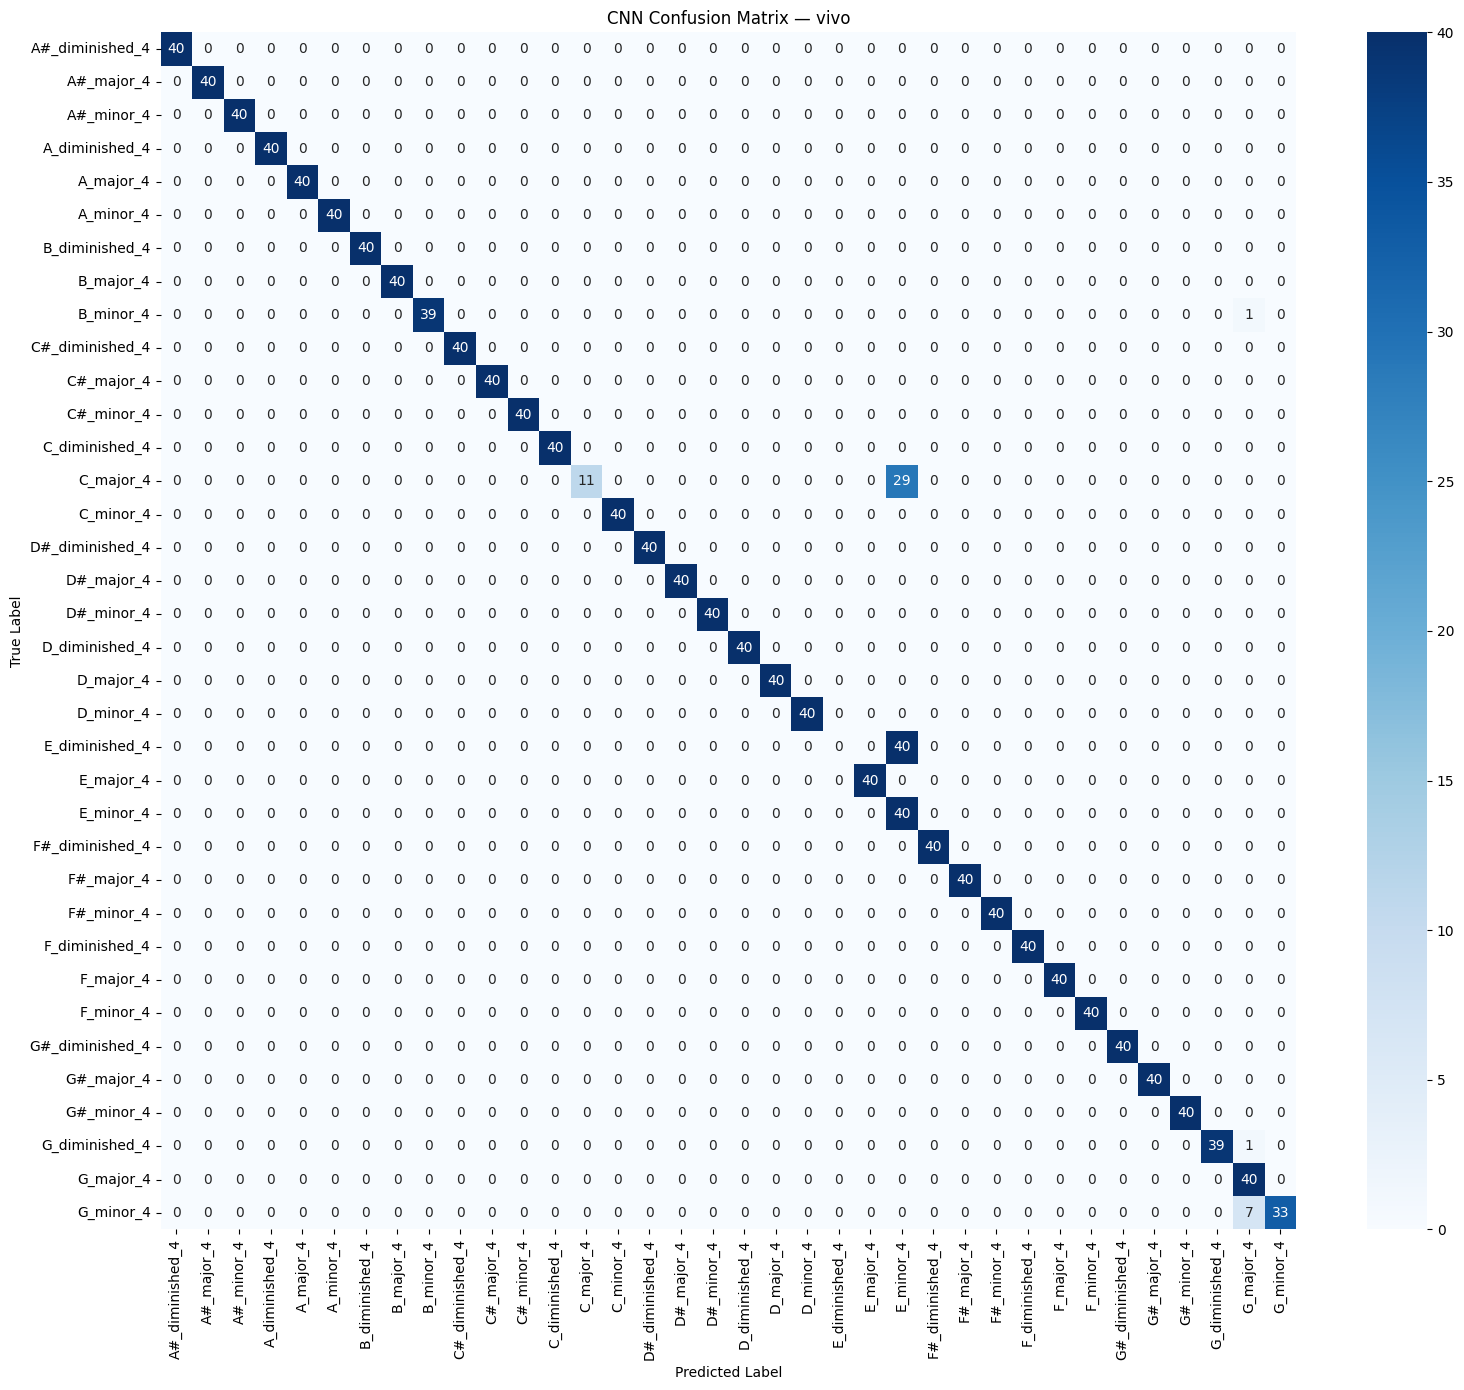

Wrote:
  /home/seya/code/chord-detection/training/notebooks/vivo/cnn-eval-results/summary.csv
  /home/seya/code/chord-detection/training/notebooks/vivo/cnn-eval-results/classification_report.csv
  /home/seya/code/chord-detection/training/notebooks/vivo/cnn-eval-results/confusion_matrix.csv
  /home/seya/code/chord-detection/training/notebooks/vivo/cnn-eval-results/confusion_matrix.png
  /home/seya/code/chord-detection/training/notebooks/vivo/cnn-eval-results/predictions.npz
  /home/seya/code/chord-detection/training/notebooks/vivo/cnn-eval-results/per_class_metrics.csv


In [5]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

summary_path = RESULTS_DIR / "summary.csv"
report_path = RESULTS_DIR / "classification_report.csv"
cm_csv_path = RESULTS_DIR / "confusion_matrix.csv"
cm_png_path = RESULTS_DIR / "confusion_matrix.png"
pred_path = RESULTS_DIR / "predictions.npz"
per_class_path = RESULTS_DIR / "per_class_metrics.csv"

summary.to_csv(summary_path, index=False)
report_df.to_csv(report_path)

cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_df.to_csv(cm_csv_path)

per_class = report_df.drop(index=["accuracy", "macro avg", "weighted avg"], errors="ignore")
per_class.to_csv(per_class_path)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"CNN Confusion Matrix — {DATASET}")
plt.tight_layout()
plt.savefig(cm_png_path, dpi=150)
plt.show()

save_kwargs = {
    "y_true": y_true,
    "y_pred": y_pred,
    "proba": proba.astype(np.float32),
    "class_names": class_names.astype(str),
    "labels": labels.astype(str),
}
if files is not None:
    save_kwargs["files"] = np.asarray(files).astype(str)
np.savez_compressed(pred_path, **save_kwargs)

print("Wrote:")
for p in (summary_path, report_path, cm_csv_path, cm_png_path, pred_path, per_class_path):
    print(" ", p)
